# Kaggle Predict F1 Pit Stops: Circuit Maps EDA

This notebook adds circuit context to the pit-stop analysis. It follows the FastF1 circuit-info pattern used in F1 analytics notebooks: load a race session, call `get_circuit_info()`, then plot the circuit coordinates and corner annotations.

The competition dataset itself does not include track geometry, so circuit maps are an optional enrichment layer rather than a modeling dependency.

## 1. Setup

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 12, "axes.labelsize": 10, "legend.frameon": False})

TARGET = "PitNextLap"
RANDOM_STATE = 42

## 2. Load Competition Data

In [2]:
def find_data_dir() -> Path:
    candidates = [
        Path("/kaggle/input/competitions/playground-series-s6e5"),
        Path("/kaggle/input/playground-series-s6e5"),
        Path("../input/competitions/playground-series-s6e5"),
        Path("../input/playground-series-s6e5"),
        Path("data"),
        Path("../data"),
        Path("."),
    ]
    for path in candidates:
        if (path / "train.csv").exists():
            return path
    raise FileNotFoundError("Could not find train.csv. Update DATA_DIR manually.")


DATA_DIR = find_data_dir()
OUTPUT_DIR = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

train = pd.read_csv(DATA_DIR / "train.csv")
print(train.shape)
train.head()

(439140, 16)


,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


## 3. Race-Level Pit Windows

In [3]:
race_summary = (
    train.groupby(["Year", "Race"], observed=True)
    .agg(
        rows=(TARGET, "size"),
        pit_next_lap_rate=(TARGET, "mean"),
        mean_lap=("LapNumber", "mean"),
        median_tyre_life=("TyreLife", "median"),
        mean_race_progress=("RaceProgress", "mean"),
    )
    .reset_index()
    .sort_values("pit_next_lap_rate", ascending=False)
)

race_summary.head(20)

,Year,Race,rows,pit_next_lap_rate,mean_lap,median_tyre_life,mean_race_progress
70,2024,Monaco Grand Prix,6002,0.760247,31.241253,25.0,0.407214
83,2025,Belgian Grand Prix,1552,0.553479,20.563144,11.0,0.271379
6,2022,British Grand Prix,2532,0.501580,21.197077,11.0,0.295934
75,2024,Spanish Grand Prix,6040,0.501159,26.284437,12.0,0.348168
66,2024,Japanese Grand Prix,2800,0.492857,25.897500,12.0,0.346102
82,2025,Bahrain Grand Prix,3396,0.476737,23.408716,10.0,0.312617
55,2024,Azerbaijan Grand Prix,2597,0.457066,19.787062,13.0,0.263602
67,2024,Las Vegas Grand Prix,4609,0.439575,19.286396,10.0,0.257414
101,2025,Spanish Grand Prix,3947,0.417532,26.245756,11.0,0.346361
4,2022,Bahrain Grand Prix,4034,0.416708,21.068171,9.0,0.295958


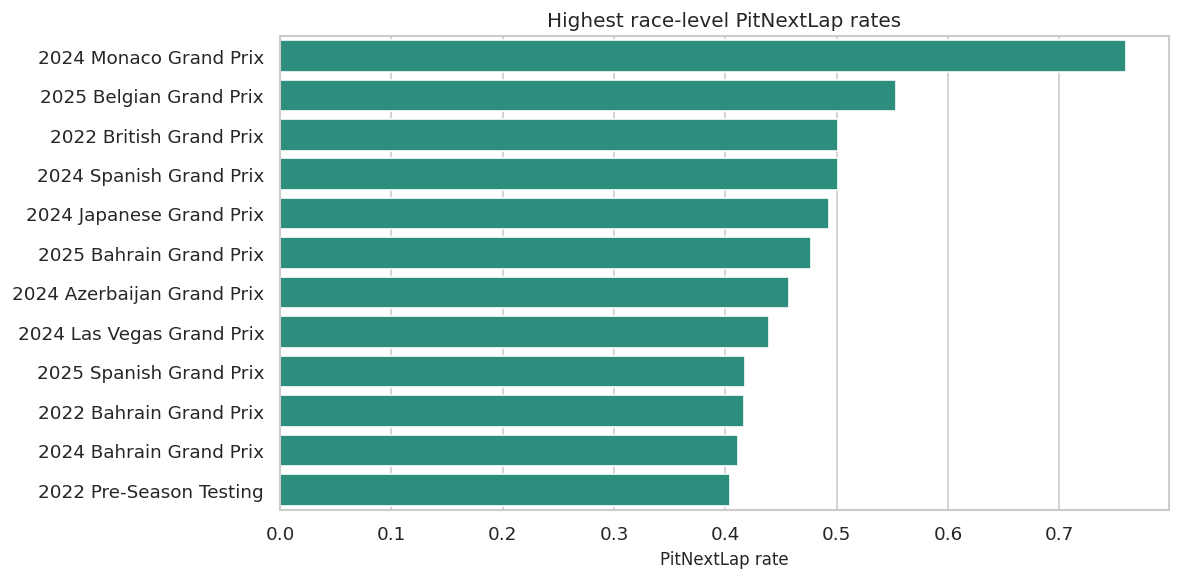

In [4]:
top_races = race_summary.head(12).copy()
top_races["label"] = top_races["Year"].astype(str) + " " + top_races["Race"].astype(str)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=top_races, y="label", x="pit_next_lap_rate", color=sns.color_palette("viridis", 8)[4], ax=ax)
ax.set_title("Highest race-level PitNextLap rates")
ax.set_xlabel("PitNextLap rate")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 4. Optional FastF1 Circuit Maps

FastF1 may not be installed or network-enabled in every Kaggle environment. The code below fails gracefully and keeps the EDA useful even without external circuit geometry.

In [5]:
try:
    import fastf1
    FASTF1_AVAILABLE = True
    cache_dir = OUTPUT_DIR / "fastf1_cache"
    cache_dir.mkdir(parents=True, exist_ok=True)
    fastf1.Cache.enable_cache(str(cache_dir))
except Exception as exc:
    FASTF1_AVAILABLE = False
    print("FastF1 unavailable. To enable circuit maps, install/import fastf1 in an environment with session data access.")
    print(exc)

FASTF1_AVAILABLE

FastF1 unavailable. To enable circuit maps, install/import fastf1 in an environment with session data access.
No module named 'fastf1'


False

In [6]:
race_name_map = {
    "Mexico City Grand Prix": "Mexico City",
    "São Paulo Grand Prix": "São Paulo",
    "Sao Paulo Grand Prix": "São Paulo",
    "British Grand Prix": "British",
    "United States Grand Prix": "United States",
    "Emilia Romagna Grand Prix": "Emilia Romagna",
    "Pre-Season Testing": None,
}


def fastf1_event_name(race: str) -> str | None:
    if race in race_name_map:
        return race_name_map[race]
    return race.replace(" Grand Prix", "")


def plot_circuit_map(year: int, race: str):
    if not FASTF1_AVAILABLE:
        print("FastF1 is not available in this environment.")
        return

    event_name = fastf1_event_name(race)
    if event_name is None:
        print(f"Skipping {race}: no race circuit map expected.")
        return

    try:
        session = fastf1.get_session(int(year), event_name, "R")
        session.load(laps=False, telemetry=False, weather=False, messages=False)
        circuit = session.get_circuit_info()
        corners = circuit.corners.copy()
    except Exception as exc:
        print(f"Could not load circuit info for {year} {race}: {exc}")
        return

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.plot(corners["X"], corners["Y"], color=sns.color_palette("viridis", 8)[5], linewidth=2)
    ax.scatter(corners["X"], corners["Y"], s=30, color=sns.color_palette("viridis", 8)[2])

    for _, row in corners.iterrows():
        label = str(row.get("Number", ""))
        ax.text(row["X"], row["Y"], label, fontsize=8, ha="center", va="center")

    ax.set_title(f"{year} {race} circuit corners")
    ax.set_aspect("equal", adjustable="box")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

## 5. Draw Example Maps

In [7]:
example_races = (
    race_summary[~race_summary["Race"].eq("Pre-Season Testing")]
    .head(4)[["Year", "Race"]]
    .itertuples(index=False, name=None)
)

for year, race in example_races:
    plot_circuit_map(year, race)

FastF1 is not available in this environment.
FastF1 is not available in this environment.
FastF1 is not available in this environment.
FastF1 is not available in this environment.


## 6. Modeling Ideas from Circuit Context

- Add circuit-level historical pit-rate features using only training folds.
- Compare pit windows by race and compound to identify circuit-specific strategy behavior.
- If external data is allowed and stable, add circuit descriptors such as corner count, track length, and pit-lane loss.
- Keep map drawing as EDA unless geometry-derived variables can be validated without leakage.